In [ ]:
import wandb
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
from functools import lru_cache
import sys
sys.path.append('../src')
from src_utils import load_whole_dataset, extract_boxed_content, get_dataset_subset

AttributeError: module 'tqdm' has no attribute 'pandas'

In [3]:
def get_metrics(run_id, project='GRPO_DIFFICULTY', entity='bpikus'):
    # Replace with your actual entity, project, and run ID
    run_path = f"{entity}/{project}/{run_id}"  

    api = wandb.Api()
    run = api.run(run_path)

    # # Download the history
    history = run.history(samples=100000)  # increase samples if your run is long


    # # 1. Drop rows with missing reward
    df =  history[["train/reward", 'train/global_step', 'train/reward_std']]
    df = df[df['train/reward'].notnull()]

    # # 2. Keep only the last entry per global_step
    df = df.groupby('train/global_step', as_index=False).last().reset_index(drop=True)

    num_gen = run.config['num_generations']
    df = df.rename(columns={'train/reward': 'train/reward_frac'})
    df['train/reward'] = (df['train/reward_frac'] * num_gen).astype(int)
    df['cumsum'] = df['train/reward'].cumsum()
    last_10_mean = np.mean(history['train/reward'].dropna().tail(10).values)
    return df, last_10_mean, history, run.name

In [11]:
entity="bpikus"
project="GRPO_dIFFICULTY"
api = wandb.Api()

runs = api.runs(f"{entity}/{project}")

df = pd.DataFrame(columns=['dataset', 'strategy','model_name', 'accuracies', 'base', 'checkpoints', 'final_acc', 'id'])
missing = []
for run in tqdm(runs):
    if run.state == 'running':
        
        print(f'Runnning: {run.name}')
        continue
    if 'strategy' not in run.name:
        continue
    if 'accuracies' in run.summary:
        splits = run.name.split('_')
        dataset_name = splits[0]
        strategy = splits[-2].replace('strategy','')
        model = splits[3].replace('-unsloth-bnb-4bit','').replace('unsloth-','').replace('Meta-','').replace('-bnb-4bit','')
        accs = run.summary['accuracies']
        base = run.summary['base_acc']
        checkpoints = run.summary['checkpoints']
        final_acc = run.summary['final_accuracy']
        df.loc[len(df)] = [
            dataset_name,
            strategy,
            model,
            accs,
            base,
            checkpoints,
            final_acc,
            run.id
        ]
    else:
        missing.append(run.name)
df = df.sort_values(by=['dataset', 'model_name', 'strategy']).reset_index(drop=True)
df.shape    

100%|██████████| 127/127 [00:05<00:00, 24.57it/s]


(48, 8)

In [ ]:
datapoint = pd.DataFrame(columns=
    ['dataset', 'strategy','model_name', 'accuracy', 'base', 'final_acc', 'checkpoint', 'num_successes_seen', 'average_reward', 'perc_learnable']
)
for i, row in tqdm(df.iterrows(), total=len(df)):
    metric_df = get_metrics(row.id)[0]
    for checkpoint, acc in zip(row.checkpoints, row.accuracies):
        datapoint.loc[len(datapoint)] = [
            row.dataset,
            row.strategy,
            row.model_name,
            acc,
            row.base,
            row.final_acc,
            checkpoint,
            metric_df['cumsum'].iloc[checkpoint-1],
            metric_df['train/reward_frac'][:checkpoint].values.mean(),
            (metric_df.iloc[0:checkpoint]['train/reward_std'] > 0).mean()
        ]
datapoint['abs_improv'] = datapoint['accuracy'] - datapoint['base']
model_sizes = {'Llama-3.1-8B-Instruct' : 8, 'Qwen3-14B': 14, 'Qwen3-4B' : 4, 'mistral-7b-instruct-v0.3' : 7, 'phi-4' : 14}
datapoint['model_size'] = datapoint['model_name'].map(model_sizes)
datapoint['relative_improvement'] = (datapoint['accuracy'] - datapoint['base']) / (1 - datapoint['base'])
last_run = datapoint[datapoint.checkpoint == 1000].reset_index(drop=True)

100%|██████████| 48/48 [00:50<00:00,  1.04s/it]


In [173]:
# cache dataset loading
@lru_cache(maxsize=None)
def load_and_subset(dataset_name, model_name, strategy):
    ds = load_whole_dataset(dataset_name, 'train', model_name)
    subset = get_dataset_subset(ds, strategy, 0.1)
    return np.mean(subset['pretrained_score'])

def get_score(row):
    dataset_name = row.dataset
    model_dict = {'Qwen3-4B': 'unsloth-Qwen3-4B-unsloth-bnb-4bit',
        'Qwen3-14B': 'unsloth-Qwen3-14B-unsloth-bnb-4bit',
        'Llama-3.1-8B-Instruct': 'unsloth-Meta-Llama-3.1-8B-Instruct-bnb-4bit',
        'mistral-7b-instruct-v0.3': 'unsloth-mistral-7b-instruct-v0.3-bnb-4bit',
        'phi-4': 'unsloth-phi-4-bnb-4bit'}
    model_name = model_dict[row.model_name]
    strategy = row.strategy
    return load_and_subset(dataset_name, model_name, strategy)

#datapoint = datapoint[datapoint.model_name!='mistral-7b-instruct-v0.3']
datapoint['train_score'] = datapoint.apply(get_score, axis=1)
datapoint

/var/folders/zq/7j74swb90ygby0pfbdm44mgw0000gn/T/ipykernel_3331/211559559.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapoint['train_score'] = datapoint.apply(get_score, axis=1)


,dataset,strategy,model_name,accuracy,base,final_acc,checkpoint,num_successes_seen,average_reward,perc_learnable,abs_improv,model_size,relative_improvement,train_score
0,gsm8k,easiest,Llama-3.1-8B-Instruct,0.467020,0.360121,0.72555,100,696,0.870000,0.570000,0.106899,8,0.167062,0.925033
1,gsm8k,easiest,Llama-3.1-8B-Instruct,0.576952,0.360121,0.72555,200,1451,0.906875,0.420000,0.216831,8,0.338863,0.925033
2,gsm8k,easiest,Llama-3.1-8B-Instruct,0.641395,0.360121,0.72555,300,2215,0.922917,0.353333,0.281274,8,0.439573,0.925033
3,gsm8k,easiest,Llama-3.1-8B-Instruct,0.685368,0.360121,0.72555,400,2995,0.935937,0.302500,0.325246,8,0.508294,0.925033
4,gsm8k,easiest,Llama-3.1-8B-Instruct,0.707354,0.360121,0.72555,500,3774,0.943500,0.274000,0.347233,8,0.542654,0.925033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,shuffleobj,random,phi-4,0.968000,0.688000,0.97600,600,4510,0.939583,0.286667,0.280000,14,0.897436,0.566667
476,shuffleobj,random,phi-4,0.960000,0.688000,0.97600,700,5304,0.947143,0.254286,0.272000,14,0.871795,0.566667
477,shuffleobj,random,phi-4,0.944000,0.688000,0.97600,800,6099,0.952969,0.228750,0.256000,14,0.820513,0.566667
478,shuffleobj,random,phi-4,0.944000,0.688000,0.97600,900,6897,0.957917,0.205556,0.256000,14,0.820513,0.566667


<Axes: xlabel='perc_learnable', ylabel='train_score'>

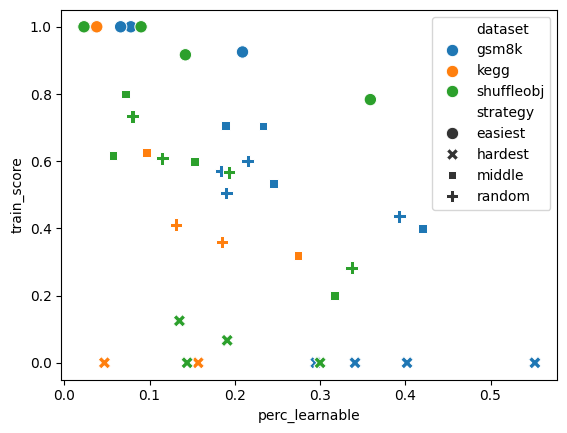

In [108]:
sns.scatterplot(
    data=last_run,
    x="perc_learnable",
    y="train_score",
    hue="dataset",
    style="strategy",   # optional: to differentiate strategies too
    s=80
)

Top 10 predictor combinations with interactions by R^2 (log-error):
('train_score', 'base', 'average_reward', 'perc_learnable', 'num_successes_seen'): R^2(log-error) = 0.8252
('base', 'average_reward', 'perc_learnable', 'num_successes_seen'): R^2(log-error) = 0.8025
('train_score', 'base', 'perc_learnable', 'num_successes_seen'): R^2(log-error) = 0.7848
('base', 'perc_learnable', 'num_successes_seen'): R^2(log-error) = 0.7461
('train_score', 'base', 'average_reward', 'perc_learnable'): R^2(log-error) = 0.7139
('train_score', 'base', 'perc_learnable'): R^2(log-error) = 0.6986
('base', 'average_reward', 'perc_learnable'): R^2(log-error) = 0.6452
('base', 'perc_learnable'): R^2(log-error) = 0.6334
('train_score', 'base', 'average_reward', 'num_successes_seen'): R^2(log-error) = 0.5856
('train_score', 'base', 'average_reward'): R^2(log-error) = 0.5774


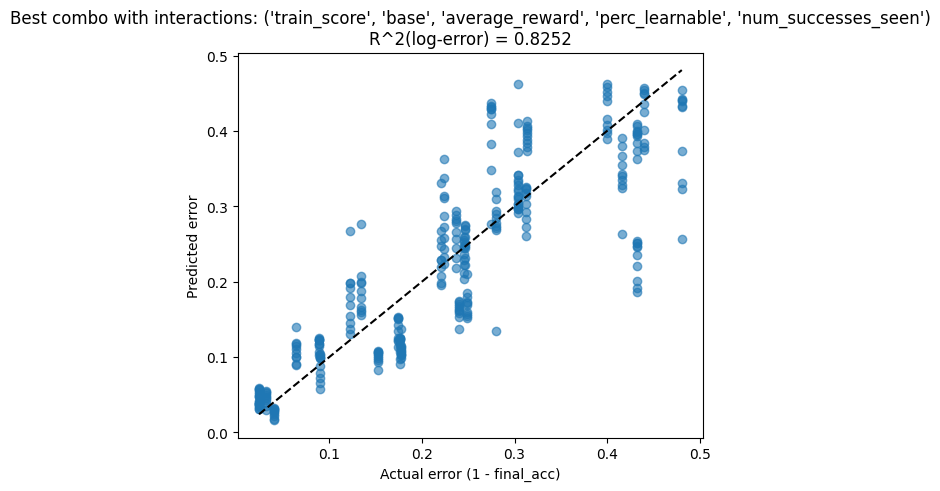

In [160]:
df = last_run[last_run.dataset!= 'kegg'].copy()
df = last_run.copy()
df = datapoint.copy()
df = datapoint[datapoint.dataset!= 'kegg'].copy()

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score,  mean_squared_error
from itertools import combinations, product
from sklearn.linear_model import LinearRegression, Ridge

df["error"] = 1 - df["final_acc"]

# Candidate predictors
predictors = ["train_score", "base", "average_reward", "perc_learnable", "num_successes_seen"]

# Log-transform features
log_features = {p: np.log(df[p].values + 1e-8) for p in predictors}

# Target transform
y_log = np.log(df["error"].values + 1e-8)

# Optional categorical offsets
dataset_offsets = pd.get_dummies(df["dataset"], drop_first=True).values if "dataset" in df.columns else None

# -------------------------------------------------
# Generate all non-empty combinations of predictors
# -------------------------------------------------
results = []

for r in range(1, len(predictors)+1):
    for combo in combinations(predictors, r):
        X_log = np.vstack([log_features[p] for p in combo]).T
        
        # Polynomial terms (squared features)
        X_poly = np.hstack([X_log, X_log**2])
        
        # Pairwise interaction terms
        if len(combo) > 1:
            for i in range(len(combo)):
                for j in range(i+1, len(combo)):
                    interaction = (X_log[:,i] * X_log[:,j]).reshape(-1,1)
                    X_poly = np.hstack([X_poly, interaction])
        
        # Add dataset offsets if available
        if dataset_offsets is not None:
            X_poly = np.hstack([X_poly, dataset_offsets])
        
        # Fit Ridge regression in log-space
        lr = Ridge(alpha=1e-3)
        lr.fit(X_poly, y_log)
        yhat_log = lr.predict(X_poly)
        
        # Compute R^2 in log-space
        r2 = r2_score(y_log, yhat_log)
        results.append({
            "predictors": combo,
            "r2_log": r2
        })

# Sort results by R^2 (descending)
results = sorted(results, key=lambda x: x["r2_log"], reverse=True)
print("Top 10 predictor combinations with interactions by R^2 (log-error):")
for r in results[:10]:
    print(f"{r['predictors']}: R^2(log-error) = {r['r2_log']:.4f}")

# -------------------------------------------------
# Plot best combination
# -------------------------------------------------
best_combo = results[0]['predictors']
X_log_best = np.vstack([log_features[p] for p in best_combo]).T
X_poly_best = np.hstack([X_log_best, X_log_best**2])

# Add pairwise interactions
if len(best_combo) > 1:
    for i in range(len(best_combo)):
        for j in range(i+1, len(best_combo)):
            interaction = (X_log_best[:,i] * X_log_best[:,j]).reshape(-1,1)
            X_poly_best = np.hstack([X_poly_best, interaction])

if dataset_offsets is not None:
    X_poly_best = np.hstack([X_poly_best, dataset_offsets])

lr_best = Ridge(alpha=1e-3).fit(X_poly_best, y_log)
yhat_best = np.exp(lr_best.predict(X_poly_best))  # back to original error

plt.figure(figsize=(6,5))
plt.scatter(df["error"], yhat_best, alpha=0.6)
plt.plot([df["error"].min(), df["error"].max()], [df["error"].min(), df["error"].max()], 'k--')
plt.xlabel("Actual error (1 - final_acc)")
plt.ylabel("Predicted error")
plt.title(f"Best combo with interactions: {best_combo}\nR^2(log-error) = {results[0]['r2_log']:.4f}")
plt.show()

In [135]:
datapoint

,dataset,strategy,model_name,accuracy,base,final_acc,checkpoint,num_successes_seen,average_reward,perc_learnable,abs_improv,model_size,relative_improvement,train_score
0,gsm8k,easiest,Llama-3.1-8B-Instruct,0.467020,0.360121,0.72555,100,696,0.870000,0.570000,0.106899,8,0.167062,0.925033
1,gsm8k,easiest,Llama-3.1-8B-Instruct,0.576952,0.360121,0.72555,200,1451,0.906875,0.420000,0.216831,8,0.338863,0.925033
2,gsm8k,easiest,Llama-3.1-8B-Instruct,0.641395,0.360121,0.72555,300,2215,0.922917,0.353333,0.281274,8,0.439573,0.925033
3,gsm8k,easiest,Llama-3.1-8B-Instruct,0.685368,0.360121,0.72555,400,2995,0.935937,0.302500,0.325246,8,0.508294,0.925033
4,gsm8k,easiest,Llama-3.1-8B-Instruct,0.707354,0.360121,0.72555,500,3774,0.943500,0.274000,0.347233,8,0.542654,0.925033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,shuffleobj,random,phi-4,0.968000,0.688000,0.97600,600,4510,0.939583,0.286667,0.280000,14,0.897436,0.566667
476,shuffleobj,random,phi-4,0.960000,0.688000,0.97600,700,5304,0.947143,0.254286,0.272000,14,0.871795,0.566667
477,shuffleobj,random,phi-4,0.944000,0.688000,0.97600,800,6099,0.952969,0.228750,0.256000,14,0.820513,0.566667
478,shuffleobj,random,phi-4,0.944000,0.688000,0.97600,900,6897,0.957917,0.205556,0.256000,14,0.820513,0.566667


Best predictor combo: ('train_score', 'base', 'model_size'), R^2 = 0.5654
LaTeX formula for Chinchilla-style scaling law:
$$\text{error} = 0.400 \cdot train_score^{0.016} \cdot base^{-0.905} \cdot model_size^{-0.577}$$


<>:85: SyntaxWarning: invalid escape sequence '\c'
<>:85: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zq/7j74swb90ygby0pfbdm44mgw0000gn/T/ipykernel_3331/2763905325.py:85: SyntaxWarning: invalid escape sequence '\c'
  formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"


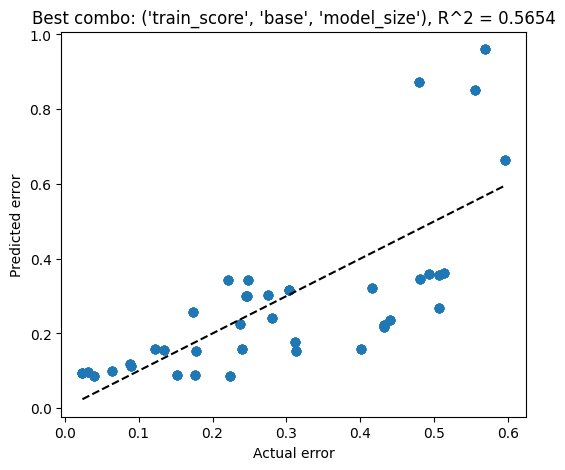

In [152]:
df = last_run[last_run.dataset!= 'kegg'].copy()
df = last_run.copy()
df = datapoint.copy()
#df = datapoint[datapoint.dataset!= 'kegg'].copy()

# -------------------------------------------------
# Prepare target and predictors
# -------------------------------------------------
use_interactions = False

df["error"] = 1 - df["final_acc"]

predictors = ["train_score", "base", 'checkpoint', 'model_size']#, "average_reward", "perc_learnable", "num_successes_seen"]  # Add other predictors if desired
log_features = {p: np.log(df[p].values + 1e-8) for p in predictors}
y_log = np.log(df["error"].values + 1e-8)

dataset_offsets = pd.get_dummies(df["dataset"], drop_first=True).values if "dataset" in df.columns else None

# ----------------------------
# Fit all combinations
# ----------------------------
results = []
models_info = []

for r in range(1, len(predictors)+1):
    for combo in combinations(predictors, r):
        X_log = np.vstack([log_features[p] for p in combo]).T
        
        # Start with only main effects (no x^2)
        X_poly = X_log.copy()
        
        # Pairwise interactions (only if flag is True)
        if use_interactions and len(combo) > 1:
            for i in range(len(combo)):
                for j in range(i+1, len(combo)):
                    interaction = (X_log[:,i] * X_log[:,j]).reshape(-1,1)
                    X_poly = np.hstack([X_poly, interaction])
        
        # Dataset offsets
        if dataset_offsets is not None:
            X_poly = np.hstack([X_poly, dataset_offsets])
        
        lr = Ridge(alpha=1e-3)
        lr.fit(X_poly, y_log)
        yhat_log = lr.predict(X_poly)
        r2 = r2_score(y_log, yhat_log)
        
        results.append({
            "predictors": combo,
            "r2_log": r2
        })
        models_info.append((combo, lr, X_poly))

# ----------------------------
# Identify top model
# ----------------------------
best_idx = np.argmax([r['r2_log'] for r in results])
best_combo, best_model, best_X = models_info[best_idx]
best_r2 = results[best_idx]['r2_log']

print(f"Best predictor combo: {best_combo}, R^2 = {best_r2:.4f}")

# ----------------------------
# Build LaTeX formula
# ----------------------------
coef = best_model.coef_
intercept = best_model.intercept_

terms = []
n_features = len(best_combo)

# original log features
for i, name in enumerate(best_combo):
    terms.append(f"{name}^{{{coef[i]:.3f}}}")

# interaction terms (only if flag is True)
interaction_start = n_features
k = 0
if use_interactions and len(best_combo) > 1:
    for i in range(len(best_combo)):
        for j in range(i+1, len(best_combo)):
            terms.append(f"({best_combo[i]} * {best_combo[j]})^{{{coef[interaction_start+k]:.3f}}}")
            k += 1

formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"
print("LaTeX formula for Chinchilla-style scaling law:")
print(formula_latex)

# ----------------------------
# Plot predicted vs actual
# ----------------------------
yhat_best = np.exp(best_model.predict(best_X))
plt.figure(figsize=(6,5))
plt.scatter(df["error"], yhat_best, alpha=0.6)
plt.plot([df["error"].min(), df["error"].max()], [df["error"].min(), df["error"].max()], 'k--')
plt.xlabel("Actual error")
plt.ylabel("Predicted error")
plt.title(f"Best combo: {best_combo}, R^2 = {best_r2:.4f}")
plt.show()

In [174]:
datapoint.columns

Index(['dataset', 'strategy', 'model_name', 'accuracy', 'base', 'final_acc',
       'checkpoint', 'num_successes_seen', 'average_reward', 'perc_learnable',
       'abs_improv', 'model_size', 'relative_improvement', 'train_score'],
      dtype='object')

In [180]:
df = datapoint.copy()
use_interactions = False  # set True to add interactions

# ----------------------------
# Prepare target and features
# ----------------------------
df_first = df[df['checkpoint'] == 100].copy()  # first checkpoint
df_first['error'] = 1 - df_first['final_acc']

pretrain_features = ['model_size', 'base', 'train_score']
early_features = ['perc_learnable']#'accuracy', 'average_reward', 'perc_learnable']

dataset_offsets = pd.get_dummies(df_first['dataset'], drop_first=True).values if 'dataset' in df_first.columns else None

# Log-transform features
log_features = {f: np.log(df_first[f].values + 1e-8) for f in pretrain_features + early_features}
y_log = np.log(df_first['error'].values + 1e-8)

# ----------------------------
# Try all combinations
# ----------------------------
results = []

for r_pre in range(1, len(pretrain_features)+1):
    for r_early in range(1, len(early_features)+1):
        for pre_combo in combinations(pretrain_features, r_pre):
            for early_combo in combinations(early_features, r_early):
                combo = pre_combo + early_combo
                X_log = np.vstack([log_features[f] for f in combo]).T

                # Optionally add pairwise interactions
                X_poly = X_log.copy()
                if use_interactions and len(combo) > 1:
                    for i in range(len(combo)):
                        for j in range(i+1, len(combo)):
                            interaction = (X_log[:,i] * X_log[:,j]).reshape(-1,1)
                            X_poly = np.hstack([X_poly, interaction])

                # Add dataset offsets if available
                if dataset_offsets is not None:
                    X_poly = np.hstack([X_poly, dataset_offsets])

                # Fit Ridge regression
                lr = Ridge(alpha=1e-3)
                lr.fit(X_poly, y_log)
                yhat_log = lr.predict(X_poly)
                r2 = r2_score(y_log, yhat_log)

                results.append({
                    'pretrain_features': pre_combo,
                    'early_features': early_combo,
                    'r2_log': r2
                })

# ----------------------------
# Sort and report top results
# ----------------------------
results_sorted = sorted(results, key=lambda x: x['r2_log'], reverse=True)
print("Top 10 combinations by R^2 (log-error):")
for r in results_sorted:
    print(f"Pretrain: {r['pretrain_features']}, Early: {r['early_features']}, R^2 = {r['r2_log']:.4f}")


Top 10 combinations by R^2 (log-error):
Pretrain: ('model_size', 'base', 'train_score'), Early: ('perc_learnable',), R^2 = 0.6748
Pretrain: ('model_size', 'base'), Early: ('perc_learnable',), R^2 = 0.6395
Pretrain: ('base', 'train_score'), Early: ('perc_learnable',), R^2 = 0.5576
Pretrain: ('model_size', 'train_score'), Early: ('perc_learnable',), R^2 = 0.5415
Pretrain: ('base',), Early: ('perc_learnable',), R^2 = 0.5296
Pretrain: ('model_size',), Early: ('perc_learnable',), R^2 = 0.5247
Pretrain: ('train_score',), Early: ('perc_learnable',), R^2 = 0.3187


R^2 (log-error) = 0.7400
LaTeX formula for Chinchilla-style scaling law:
$$\text{error} = 0.339 \cdot model_size^{-0.570} \cdot accuracy^{-1.130} \cdot average_reward^{0.389} \cdot perc_learnable^{-0.330}$$


<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zq/7j74swb90ygby0pfbdm44mgw0000gn/T/ipykernel_3331/2778645873.py:32: SyntaxWarning: invalid escape sequence '\c'
  formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"


Text(0.5, 1.0, "Top combination: Pretrain=('model_size',), Early=('accuracy', 'average_reward', 'perc_learnable')\nR^2 = 0.7400")

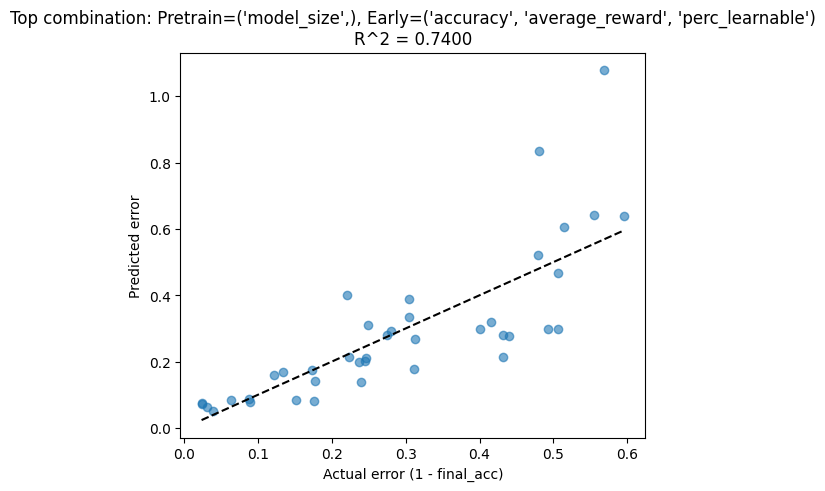

In [171]:
# ----------------------------
# Features for top combination
# ----------------------------
pretrain_features = ('model_size',)
early_features = ('accuracy', 'average_reward', 'perc_learnable')
all_features = pretrain_features + early_features

X_log = np.vstack([np.log(df_first[f].values + 1e-8) for f in all_features]).T
y_log = np.log(df_first['error'].values + 1e-8)

# Optional: add dataset offsets if needed
dataset_offsets = pd.get_dummies(df_first['dataset'], drop_first=True).values if 'dataset' in df_first.columns else None
if dataset_offsets is not None:
    X_log = np.hstack([X_log, dataset_offsets])

# ----------------------------
# Fit Ridge regression
# ----------------------------
lr = Ridge(alpha=1e-3)
lr.fit(X_log, y_log)
yhat_log = lr.predict(X_log)
r2 = r2_score(y_log, yhat_log)
print(f"R^2 (log-error) = {r2:.4f}")

# ----------------------------
# Build LaTeX formula
# ----------------------------
coef = lr.coef_
intercept = lr.intercept_

terms = [f"{f}^{{{coef[i]:.3f}}}" for i, f in enumerate(all_features)]
formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"
print("LaTeX formula for Chinchilla-style scaling law:")
print(formula_latex)

# ----------------------------
# Plot predicted vs actual
# ----------------------------
yhat = np.exp(yhat_log)  # back to original error
plt.figure(figsize=(6,5))
plt.scatter(df_first['error'], yhat, alpha=0.6)
plt.plot([df_first['error'].min(), df_first['error'].max()],
         [df_first['error'].min(), df_first['error'].max()], 'k--')
plt.xlabel("Actual error (1 - final_acc)")
plt.ylabel("Predicted error")
plt.title(f"Top combination: Pretrain={pretrain_features}, Early={early_features}\nR^2 = {r2:.4f}")

In [213]:
df.strategy.value_counts()

strategy
easiest    100
hardest    100
middle     100
random     100
Name: count, dtype: int64

In [221]:
df = datapoint.copy()
train_df = df[df.dataset != 'gsm8k']
test_df = df[df.dataset == 'gsm8k']


use_interactions = False  # set True to add pairwise interactions
all_features = ['model_size', 'base', 'train_score', 'perc_learnable', 'accuracy', 'average_reward', 'perc_learnable']  # combine pretrain + early

train_first = train_df[train_df['checkpoint'] == 100].copy()
train_first['error'] = 1 - train_first['final_acc']

test_first = test_df[test_df['checkpoint'] == 100].copy()
test_first['error'] = 1 - test_first['final_acc']

# Train offsets
dataset_dummies_train = pd.get_dummies(train_first['dataset'], drop_first=False)
dataset_offsets_train = dataset_dummies_train.values

# Test offsets: reindex to match train columns
dataset_dummies_test = pd.get_dummies(test_first['dataset'], drop_first=False)
dataset_dummies_test = dataset_dummies_test.reindex(columns=dataset_dummies_train.columns, fill_value=0)
dataset_offsets_test = dataset_dummies_test.values

# Log-transform features
log_features_train = {f: np.log(train_first[f].values + 1e-8) for f in all_features}
y_train_log = np.log(train_first['error'].values + 1e-8)

log_features_test = {f: np.log(test_first[f].values + 1e-8) for f in all_features}
y_test_log = np.log(test_first['error'].values + 1e-8)

# ----------------------------
# Try all non-empty combinations of all features
# ----------------------------
seen_combos = set()
results = []

for r in range(1, len(all_features)+1):
    for combo in combinations(all_features, r):
        combo_set = frozenset(combo)
        if combo_set in seen_combos:
            continue
        seen_combos.add(combo_set)

        # Build training feature matrix
        X_train = np.vstack([log_features_train[f] for f in combo]).T

        # Optionally add pairwise interactions
        X_train_poly = X_train.copy()
        if use_interactions and len(combo) > 1:
            for i in range(len(combo)):
                for j in range(i+1, len(combo)):
                    interaction = (X_train[:,i] * X_train[:,j]).reshape(-1,1)
                    X_train_poly = np.hstack([X_train_poly, interaction])

        # Add dataset offsets
        if dataset_offsets_train is not None:
            X_train_poly = np.hstack([X_train_poly, dataset_offsets_train])

        # Build test feature matrix
        X_test = np.vstack([log_features_test[f] for f in combo]).T
        X_test_poly = X_test.copy()
        if use_interactions and len(combo) > 1:
            for i in range(len(combo)):
                for j in range(i+1, len(combo)):
                    interaction = (X_test[:,i] * X_test[:,j]).reshape(-1,1)
                    X_test_poly = np.hstack([X_test_poly, interaction])

        if dataset_offsets_test is not None:
            X_test_poly = np.hstack([X_test_poly, dataset_offsets_test])

        # Fit Ridge on train, evaluate on test
        lr = Ridge(alpha=1e-3)
        lr.fit(X_train_poly, y_train_log)
        yhat_test_log = lr.predict(X_test_poly)
        r2_test = r2_score(y_test_log, yhat_test_log)

        results.append({
            'features': combo,
            'r2_test_log': r2_test
        })

# ----------------------------
# Sort and report top results
# ----------------------------
results_sorted = sorted(results, key=lambda x: x['r2_test_log'], reverse=True)
print("Top 10 feature combinations by R^2 on test set (log-error):")
for r in results_sorted[:10]:
    print(f"{len(r['features'])} Features: {r['features']}, R^2 = {r['r2_test_log']:.4f}")


Top 10 feature combinations by R^2 on test set (log-error):
3 Features: ('base', 'perc_learnable', 'average_reward'), R^2 = 0.5908
4 Features: ('base', 'train_score', 'perc_learnable', 'average_reward'), R^2 = 0.4799
3 Features: ('perc_learnable', 'accuracy', 'average_reward'), R^2 = 0.4605
5 Features: ('model_size', 'base', 'train_score', 'perc_learnable', 'average_reward'), R^2 = 0.2332
4 Features: ('model_size', 'base', 'perc_learnable', 'average_reward'), R^2 = 0.2222
4 Features: ('train_score', 'perc_learnable', 'accuracy', 'average_reward'), R^2 = 0.1840
2 Features: ('accuracy', 'average_reward'), R^2 = 0.0596
3 Features: ('train_score', 'perc_learnable', 'accuracy'), R^2 = 0.0090
3 Features: ('base', 'train_score', 'perc_learnable'), R^2 = 0.0057
4 Features: ('model_size', 'perc_learnable', 'accuracy', 'average_reward'), R^2 = 0.0050


R^2 on test set (log-error) = 0.5908
LaTeX formula for Chinchilla-style scaling law (train → test):
$$\text{error} = 0.052 \cdot base^{-1.920} \cdot perc_learnable^{-0.390} \cdot average_reward^{0.437}$$


<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zq/7j74swb90ygby0pfbdm44mgw0000gn/T/ipykernel_3331/984060062.py:26: SyntaxWarning: invalid escape sequence '\c'
  formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"


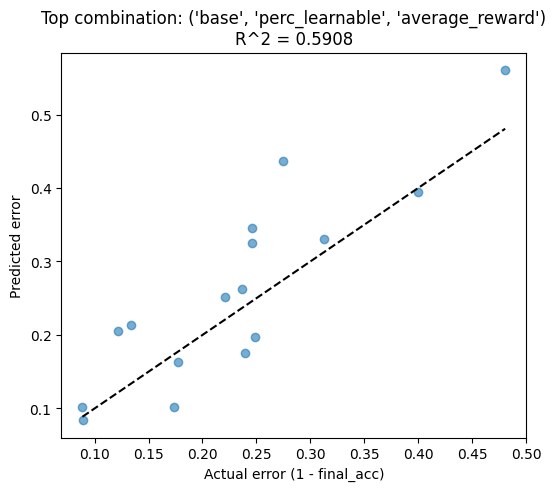

In [223]:
all_features = ('base', 'perc_learnable', 'average_reward')

# Build train matrix
X_train = np.vstack([np.log(train_first[f].values + 1e-8) for f in all_features]).T
if dataset_offsets_train is not None:
    X_train = np.hstack([X_train, dataset_offsets_train])
y_train_log = np.log(train_first['error'].values + 1e-8)

# Build test matrix
X_test = np.vstack([np.log(test_first[f].values + 1e-8) for f in all_features]).T
if dataset_offsets_test is not None:
    X_test = np.hstack([X_test, dataset_offsets_test])
y_test_log = np.log(test_first['error'].values + 1e-8)

# Fit Ridge on train, evaluate on test
lr = Ridge(alpha=1e-3)
lr.fit(X_train, y_train_log)
yhat_test_log = lr.predict(X_test)
r2_test = r2_score(y_test_log, yhat_test_log)
print(f"R^2 on test set (log-error) = {r2_test:.4f}")

# Build LaTeX formula (only for the selected features, ignoring dataset offsets)
coef = lr.coef_[:len(all_features)]  # first n coefficients correspond to features
intercept = lr.intercept_
terms = [f"{f}^{{{coef[i]:.3f}}}" for i, f in enumerate(all_features)]
formula_latex = r"$$\text{error} = " + f"{np.exp(intercept):.3f}" + r" \cdot " + " \cdot ".join(terms) + "$$"
print("LaTeX formula for Chinchilla-style scaling law (train → test):")
print(formula_latex)

# Plot predicted vs actual on test set
yhat_test = np.exp(yhat_test_log)  # back to original error
plt.figure(figsize=(6,5))
plt.scatter(test_first['error'], yhat_test, alpha=0.6)
plt.plot([test_first['error'].min(), test_first['error'].max()],
         [test_first['error'].min(), test_first['error'].max()], 'k--')
plt.xlabel("Actual error (1 - final_acc)")
plt.ylabel("Predicted error")
plt.title(f"Top combination: {all_features}\nR^2 = {r2_test:.4f}")
plt.show()